# Лабораторная работа 8 - Анализ и прогнозирование временного ряда.


## # Прогнозирование временного ряда AirPassengers

**Методы:**
- SARIMA (авторегрессия с сезонностью)
- Символьная регрессия (gplearn)
- МГУА COMBI (линейный) и RIA (нелинейный) – ручная реализация

In [ ]:
!pip install gplearn pmdarima

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from gplearn.genetic import SymbolicRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import PolynomialFeatures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


/tmp/ipykernel_7455/802305860.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data['Month'] = pd.date_range(start='1949-01', periods=len(data), freq='M')


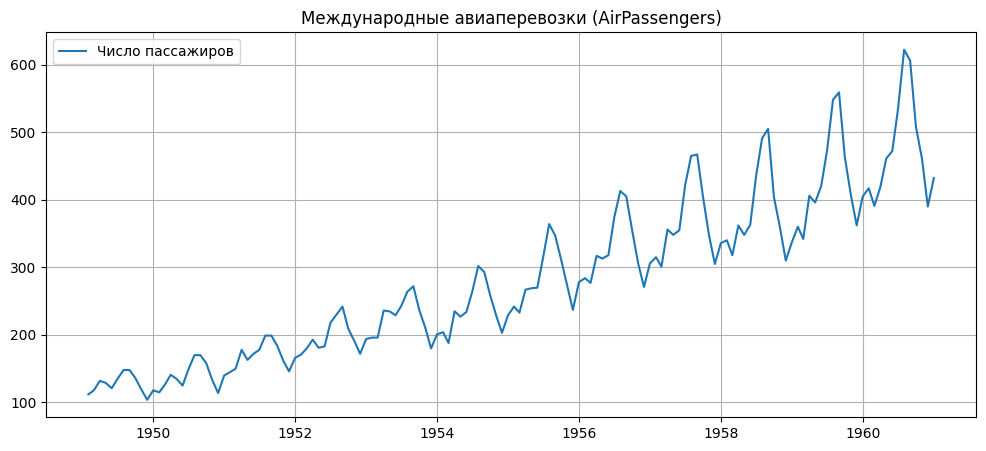

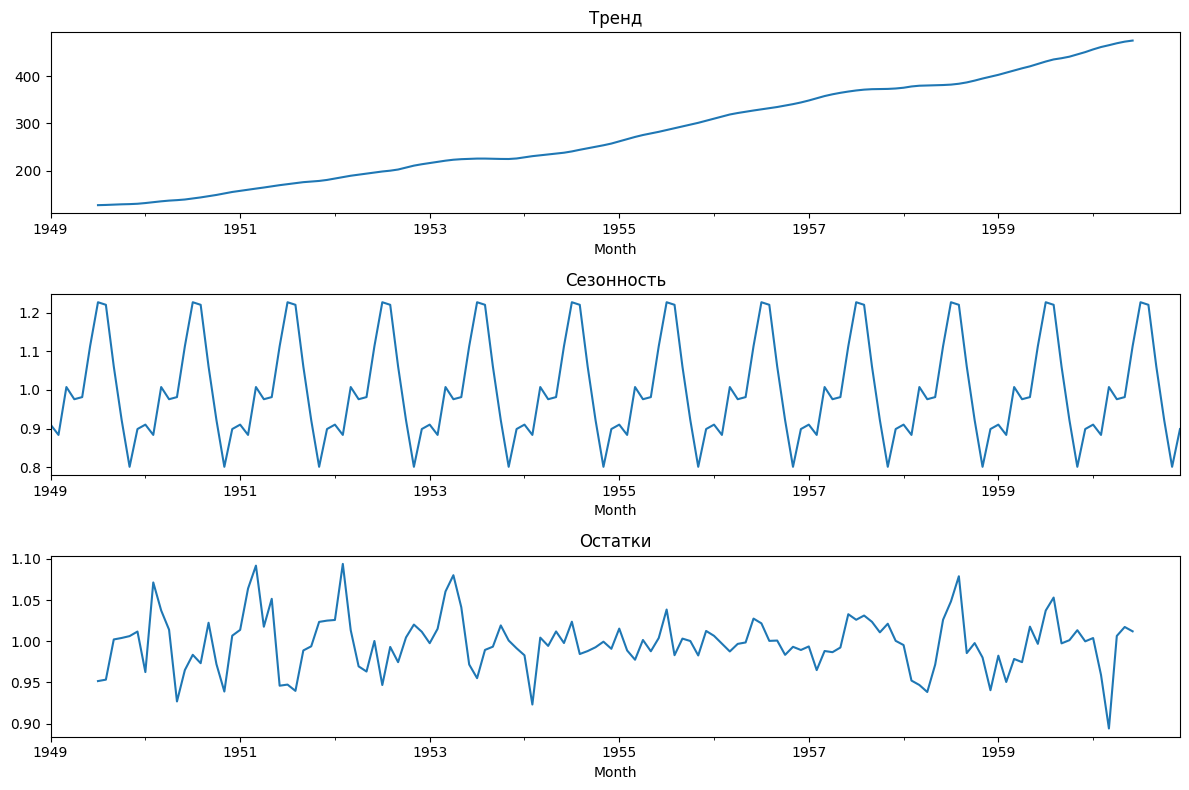

In [ ]:
# Загрузка данных AirPassengers
data = sm.datasets.get_rdataset('AirPassengers').data
data['Month'] = pd.date_range(start='1949-01', periods=len(data), freq='M')
data.set_index('Month', inplace=True)
ts = data['value'].astype(float)

# График ряда
plt.figure(figsize=(12,5))
plt.plot(ts, label='Число пассажиров')
plt.title('Международные авиаперевозки (AirPassengers)')
plt.legend()
plt.grid(True)
plt.show()

# Декомпозиция (тренд, сезонность, остатки)
decomp = seasonal_decompose(ts, model='multiplicative', period=12)
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(12,8))
decomp.trend.plot(ax=ax1, title='Тренд')
decomp.seasonal.plot(ax=ax2, title='Сезонность')
decomp.resid.plot(ax=ax3, title='Остатки')
plt.tight_layout()
plt.show()

Оставляем последние 12 месяцев (1960 год) для тестирования.  
Обучающая выборка: 1949–1959 (132 точки).

In [ ]:
train = ts.iloc[:-12]  # 1949-01 to 1959-12
test = ts.iloc[-12:]   # 1960-01 to 1960-12

print(f"Обучающая выборка: {len(train)} точек")
print(f"Тестовая выборка: {len(test)} точек")

Обучающая выборка: 132 точек
Тестовая выборка: 12 точек


### 1. SARIMA (сезонная авторегрессия)
Автоматический подбор параметров с помощью `auto_arima` из `pmdarima`.

In [ ]:
# Автоматический подбор SARIMA
auto_model = auto_arima(train, seasonal=True, m=12,
                        trace=False, error_action='ignore',
                        suppress_warnings=True, stepwise=True)
print("Лучшие параметры SARIMA:", auto_model.order, "x", auto_model.seasonal_order)

# Обучение финальной модели
model_sarima = SARIMAX(train, order=auto_model.order,
                       seasonal_order=auto_model.seasonal_order)
fitted_sarima = model_sarima.fit(disp=False)
forecast_sarima = fitted_sarima.forecast(steps=12)

Лучшие параметры SARIMA: (3, 0, 0) x (0, 1, 0, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


### 2. Символьная регрессия (gplearn)
Создаём лаговые признаки (t-1, t-2, ..., t-12) и обучаем SymbolicRegressor.

In [ ]:
def create_lag_features(series, lags):
    df = pd.DataFrame({'y': series})
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df.dropna(inplace=True)
    X = df.drop('y', axis=1)
    y = df['y']
    return X, y

lags = 12
X_train_sr, y_train_sr = create_lag_features(train, lags)
X_test_sr, y_test_sr = create_lag_features(pd.concat([train, test]), lags)  # используем полный ряд для генерации тестовых лагов
# Для теста берём только последние 12 строк (соответствуют тестовому периоду)
X_test_sr = X_test_sr.iloc[-12:]
y_test_sr = y_test_sr.iloc[-12:]

# Нормализация признаков
scaler_sr = StandardScaler()
X_train_scaled = scaler_sr.fit_transform(X_train_sr)
X_test_scaled = scaler_sr.transform(X_test_sr)

In [ ]:
sr = SymbolicRegressor(population_size=2000, generations=10,
                       stopping_criteria=0.01, const_range=(-5,5),
                       function_set=('add','sub','mul','div','sqrt','sin','cos','log'),
                       random_state=42, verbose=0)
sr.fit(X_train_scaled, y_train_sr)
forecast_sr = sr.predict(X_test_scaled)

### 3. МГУА COMBI (линейный) и RIA (нелинейный)
Библиотека `gmdh` несовместима с Python 3.12, поэтому реализуем алгоритмы вручную.
Используем те же лаговые признаки.

In [ ]:
class CombiGMDH:
    """Полиномиальный МГУА: все признаки степени ≤2, отбор лучших, линейная регрессия."""
    def __init__(self, max_degree=2, n_select=15):
        self.max_degree = max_degree
        self.n_select = n_select
        self.poly = PolynomialFeatures(degree=max_degree, include_bias=False)
        self.selector = SelectKBest(score_func=f_regression, k=n_select)
        self.model = LinearRegression()
    def fit(self, X, y):
        X_poly = self.poly.fit_transform(X)
        X_sel = self.selector.fit_transform(X_poly, y)
        self.model.fit(X_sel, y)
        self.idx = self.selector.get_support(indices=True)
        return self
    def predict(self, X):
        X_poly = self.poly.transform(X)
        X_sel = X_poly[:, self.idx]
        return self.model.predict(X_sel)

In [ ]:
class RiaGMDH:
    """Итерационный релаксационный МГУА: слои попарных комбинаций, отбор лучших нейронов."""
    def __init__(self, max_layers=2, n_best=8, test_size=0.3, random_state=42):
        self.max_layers = max_layers
        self.n_best = n_best
        self.test_size = test_size
        self.random_state = random_state

    def _create_neurons(self, n_features):
        neurons = []
        for i in range(n_features):
            neurons.append((i,i))
            for j in range(i+1, n_features):
                neurons.append((i,j))
        return neurons

    def _fit_neuron(self, X, y, i, j):
        if i == j:
            X_in = X[:, i].reshape(-1,1)
        else:
            X_in = np.column_stack([X[:,i], X[:,j]])
        model = LinearRegression().fit(X_in, y)
        pred = model.predict(X_in)
        mse = mean_squared_error(y, pred)
        return model, mse

    def fit(self, X, y):
        X_val, X_tr, y_val, y_tr = train_test_split(X, y, test_size=self.test_size,
                                                    random_state=self.random_state)
        curr_tr = X_tr.copy()
        curr_val = X_val.copy()
        self.layers_models = []
        for layer in range(self.max_layers):
            neurons = self._create_neurons(curr_tr.shape[1])
            candidates = []
            for (i,j) in neurons:
                model, _ = self._fit_neuron(curr_tr, y_tr, i, j)
                if i == j:
                    Xv = curr_val[:, i].reshape(-1,1)
                else:
                    Xv = np.column_stack([curr_val[:,i], curr_val[:,j]])
                yv_pred = model.predict(Xv)
                mse_val = mean_squared_error(y_val, yv_pred)
                candidates.append((model, mse_val, i, j))
            candidates.sort(key=lambda x: x[1])
            best = candidates[:self.n_best]
            self.layers_models.append(best)
            # новые признаки
            new_tr = []
            new_val = []
            for (model, _, i, j) in best:
                if i == j:
                    new_tr.append(model.predict(curr_tr[:, i].reshape(-1,1)))
                    new_val.append(model.predict(curr_val[:, i].reshape(-1,1)))
                else:
                    new_tr.append(model.predict(np.column_stack([curr_tr[:,i], curr_tr[:,j]])))
                    new_val.append(model.predict(np.column_stack([curr_val[:,i], curr_val[:,j]])))
            curr_tr = np.column_stack(new_tr)
            curr_val = np.column_stack(new_val)
        # лучший нейрон последнего слоя
        last_best = self.layers_models[-1][0]
        self.final_model, _, self.fi, self.fj = last_best
        return self

    def predict(self, X):
        curr = X
        for layer_models in self.layers_models:
            outputs = []
            for (model, _, i, j) in layer_models:
                if i == j:
                    outputs.append(model.predict(curr[:, i].reshape(-1,1)))
                else:
                    outputs.append(model.predict(np.column_stack([curr[:,i], curr[:,j]])))
            curr = np.column_stack(outputs)
        if self.fi == self.fj:
            return self.final_model.predict(curr[:, self.fi].reshape(-1,1))
        else:
            return self.final_model.predict(curr[:, [self.fi, self.fj]])

In [ ]:
from sklearn.model_selection import train_test_split

# Используем уже созданные X_train_sr, y_train_sr (без масштабирования)
X_train_arr = X_train_sr.values
y_train_arr = y_train_sr.values

# COMBI
combi = CombiGMDH(max_degree=2, n_select=15)
combi.fit(X_train_arr, y_train_arr)
forecast_combi = combi.predict(X_test_sr.values)

# RIA
ria = RiaGMDH(max_layers=2, n_best=8, test_size=0.3, random_state=42)
ria.fit(X_train_arr, y_train_arr)
forecast_ria = ria.predict(X_test_sr.values)

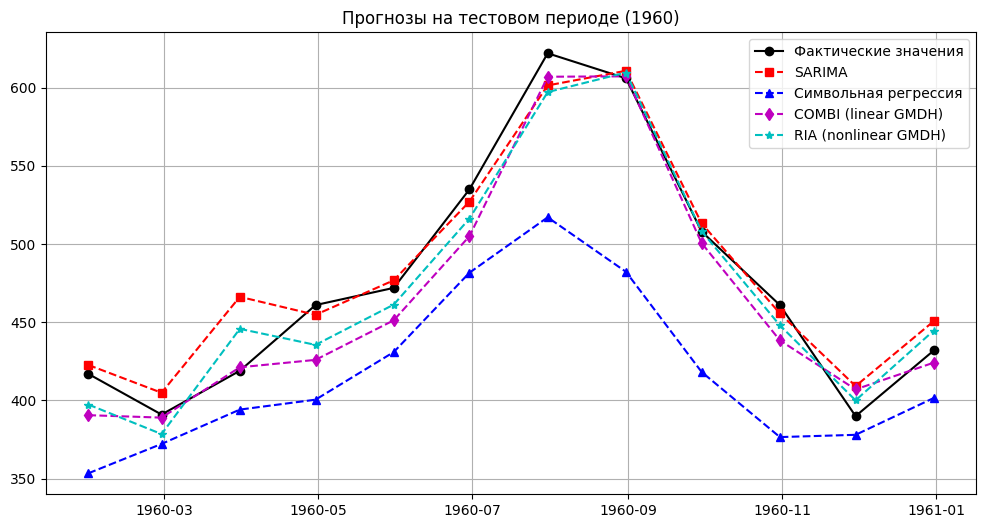

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, 'k-o', label='Фактические значения')
plt.plot(test.index, forecast_sarima, 'r--s', label='SARIMA')
plt.plot(test.index, forecast_sr, 'b--^', label='Символьная регрессия')
plt.plot(test.index, forecast_combi, 'm--d', label='COMBI (linear GMDH)')
plt.plot(test.index, forecast_ria, 'c--*', label='RIA (nonlinear GMDH)')
plt.title('Прогнозы на тестовом периоде (1960)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, mae

models_pred = {
    'SARIMA': forecast_sarima,
    'SymbolicRegressor': forecast_sr,
    'COMBI (GMDH linear)': forecast_combi,
    'RIA (GMDH nonlinear)': forecast_ria
}

print("=== Качество прогнозов (MSE / MAE) ===")
for name, pred in models_pred.items():
    mse, mae = metrics(test.values, pred)
    print(f"{name:<25}  MSE={mse:.2f}  MAE={mae:.2f}")

=== Качество прогнозов (MSE / MAE) ===
SARIMA                     MSE=317.40  MAE=13.31
SymbolicRegressor          MSE=4644.99  MAE=58.92
COMBI (GMDH linear)        MSE=366.71  MAE=15.61
RIA (GMDH nonlinear)       MSE=285.93  MAE=14.85
